<a href="https://colab.research.google.com/github/kellygauna/PDI---Laboratorio-Ordinario/blob/main/P7_EQ_2_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRACTICA #7 :** *Segmentación Óptima*
##### **EQUIPO #2:**
---

*   Kelly Estefanía de la Rosa Gauna - 2048165
*   Fatima Zoe Elisa Juárez Barrientos - 2004844
*   Melissa Rojas Reséndiz - 2132073

## **PARTE I. SEGMENTACIÓN ÓPTIMA**


***Instrucciones:*** Realiza las operaciones de segmentación a la siguiente imagen

### **EJERCICIO 1.** ***Segmentación sencilla***

Para este ejercicio se trabajó con una imagen médica cargada desde la fuente especificada, la cual se encuentra en formato RGB. Inicialmente, la imagen fue leída con OpenCV y convertida de BGR a RGB para su correcta visualización y procesamiento.

Posteriormente, se separaron los canales de color (Rojo, Verde y Azul), lo cual permite analizar la contribución de cada canal en la formación de la imagen

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


img = cv2.imread(r"Te-me_0015.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]


Para la segmentación sencilla, se generó una imagen en escala de grises mediante el promedio de los tres canales. Este método asigna el mismo peso a cada canal, lo que resulta en una conversión básica sin considerar la importancia relativa de cada componente de color.

Después, se aplicó una umbralización utilizando la función cv2.threshold(), lo que permitió segmentar la imagen en dos regiones: fondo y objeto de interés.


In [ ]:
gray_avg = ((R.astype(np.float32)+G+B)/3).astype(np.uint8)

_, seg_simple = cv2.threshold(gray_avg, 100, 255, cv2.THRESH_BINARY)

### **EJERCICIO 2.** ***Segmentación óptima.***

Para mejorar la calidad de la segmentación, se implementó un método de optimización basado en el algoritmo SLSQP, cuyo objetivo es encontrar los coeficientes óptimos para combinar los canales RGB y maximizar el contraste de la imagen en escala de grises.
Primero, se normalizaron los canales entre 0 y 1. Posteriormente, se definió una función objetivo que calcula la varianza de la imagen en escala de grises generada a partir de una combinación ponderada de los canales. La varianza se utiliza como medida de contraste, por lo que maximizarla permite obtener una imagen con mejor diferenciación entre estructuras.


In [ ]:
R_norm = R.astype(np.float32)/255
G_norm = G.astype(np.float32)/255
B_norm = B.astype(np.float32)/255

def grayscale_variance(w):
    gray = w[0]*R_norm + w[1]*G_norm + w[2]*B_norm
    gray = (gray-gray.min())/(gray.max()-gray.min())
    return -np.var(gray)


Se establecieron restricciones para asegurar que la suma de los pesos fuera igual a 1 y que cada coeficiente se encontrara entre 0 y 1. Luego, se ejecutó la función minimize() para encontrar los pesos óptimos.


In [ ]:
constraints = ({'type':'eq','fun':lambda w: np.sum(w)-1})
bounds = [(0,1),(0,1),(0,1)]
initial = [0.33,0.33,0.34]

result = minimize(grayscale_variance, initial, method='SLSQP',
                  bounds=bounds, constraints=constraints)

w_opt = result.x

Con estos coeficientes, se generó una nueva imagen en escala de grises con mayor contraste, lo que facilita la segmentación.

Posteriormente, se aplicó el mismo umbral que en la segmentación sencilla para comparar ambos resultados.


In [ ]:
gray_opt = w_opt[0]*R_norm + w_opt[1]*G_norm + w_opt[2]*B_norm
gray_opt = (gray_opt*255).astype(np.uint8)

_, seg_opt = cv2.threshold(gray_opt, 100, 255, cv2.THRESH_BINARY)

Después de la segmentación, se aplicaron operaciones morfológicas para eliminar ruido y mejorar la definición de las regiones. Se utilizó una operación de apertura (erosión seguida de dilatación) para eliminar pequeños artefactos, seguida de una dilatación para reforzar las estructuras principales como el contorno del cráneo y el tumor.

In [ ]:
kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(seg_opt, cv2.MORPH_OPEN, kernel)
clean = cv2.dilate(clean, kernel, iterations=1)

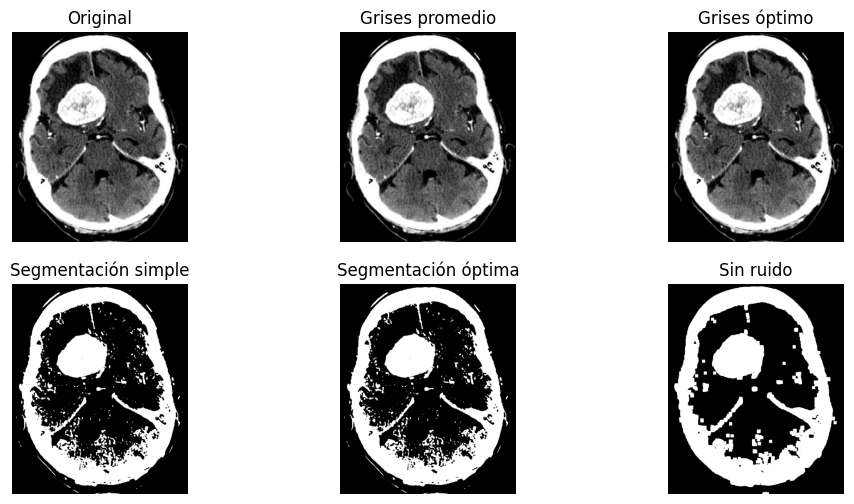

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray_avg, cmap='gray')
plt.title("Grises promedio")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(gray_opt, cmap='gray')
plt.title("Grises óptimo")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(seg_simple, cmap='gray')
plt.title("Segmentación simple")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(seg_opt, cmap='gray')
plt.title("Segmentación óptima")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(clean, cmap='gray')
plt.title("Sin ruido")
plt.axis("off")

plt.show()

Finalmente, se calculó el área del tumor contando el número de píxeles blancos en la imagen segmentada limpia. Este valor representa el área en píxeles de la región detectada como tumor, lo cual es útil para análisis cuantitativos en aplicaciones médicas.


In [ ]:
area_tumor = np.sum(clean == 255)
print("Área del tumor (pixeles):", area_tumor)

Área del tumor (pixeles): 103746
